# 🎬 TMDB — Gişe Hit Tahmini

Film vizyona girmeden, yalnızca pre-release bilgilerle hit olup olmayacağını tahmin ediyoruz.

| | Açıklama |
|---|---|
| **Soru** | Bir film gişe rekoru kırabilir mi? |
| **Özellikler** | Pre-release (bütçe, tür, stüdyo, metin...) |
| **Ana Metrik** | PR-AUC + F1 |
| **Modeller** | LightGBM, Random Forest, Logistic Regression |

### GEREKLİ KÜTÜPHANELERİ KURMA

Model eğitimi için gerekli tüm kütüphaneleri yüklüyoruz.

**Kurulacak kütüphaneler:**
- `pandas` — Veri manipülasyonu ve analizi
- `numpy` — Sayısal hesaplamalar
- `matplotlib` — Grafik ve görselleştirme
- `scikit-learn` — Machine learning (preprocessing, model eğitimi)
- `lightgbm` — Gradient boosting model (LightGBM)
- `mlflow` — Model takibi ve deney yönetimi
- `shap` — Model yorumlanabilirliği (feature importance)
- `iterative-stratification` — Çok etiketli stratified k-fold
- `ipywidgets` — İnteraktif widget'lar (verbose seçimi)
- `optuna` — Hiperparametre optimizasyonu (Bayesian arama)

In [1]:
%pip install -q pandas numpy matplotlib mlflow shap lightgbm scikit-learn iterative-stratification ipywidgets optuna

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import shap

from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold, KFold, TimeSeriesSplit,
    cross_validate, train_test_split,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve,
)

import ipywidgets as widgets
from IPython.display import display

RANDOM_STATE = 42
print('✓ Kütüphaneler yüklendi')
print(f'  MLflow: {mlflow.__version__}')
print(f'  SHAP:   {shap.__version__}')

✓ Kütüphaneler yüklendi
  MLflow: 3.11.1
  SHAP:   0.49.1


---
## 1 — Veri & Özellik Tanımları

In [3]:
from pathlib import Path

DATASET_PATH    = 'data/tmdb_model.csv'
EXPERIMENT_NAME = Path(DATASET_PATH).stem   # → "tmdb_model"

TASK_TYPE = 'binary'   # binary | multiclass | regression | timeseries | multilabel

df = pd.read_csv(DATASET_PATH)

genre_cols = [c for c in df.columns if c.startswith('genre_')]
kw_cols    = [c for c in df.columns if c.startswith('kw_')]

# Pre-release özellikler — film vizyona girmeden önce bilinebilen bilgiler
FEATURES = (
    ['budget_log', 'runtime',
    #  'popularity', 'vote_average', 'vote_count',
     'num_companies', 'num_countries', 'num_genres',
     'tagline_length', 'overview_length',
     'is_major_studio', 'is_english', 'is_us_production',
     'has_homepage', 'has_postcredit']
    + genre_cols
    + kw_cols
)

TARGET = 'hit'

df_model = df[FEATURES + [TARGET]].dropna()

X = df_model[FEATURES]
y = df_model[TARGET]


def split_data(X, y, task_type, test_size=0.2):
    """task_type'a göre veri sızıntısı olmayan train/test bölümlemesi."""
    if task_type == 'timeseries':
        split_idx = int(len(X) * (1 - test_size))
        return (X.iloc[:split_idx], X.iloc[split_idx:],
                y.iloc[:split_idx], y.iloc[split_idx:])
    else:
        stratify = y if task_type in ('binary', 'multiclass') else None
        return train_test_split(X, y, test_size=test_size,
                                stratify=stratify, random_state=RANDOM_STATE)


X_train, X_test, y_train, y_test = split_data(X, y, TASK_TYPE)

print(f'✓ Dataset       : {DATASET_PATH}  →  experiment: "{EXPERIMENT_NAME}"')
print(f'✓ Task type     : {TASK_TYPE}')
print(f'✓ Toplam  : {len(df_model):,} film  |  hit oranı: %{y.mean()*100:.1f}')
print(f'  Train   : {len(X_train):,} film  |  hit oranı: %{y_train.mean()*100:.1f}')
print(f'  Test    : {len(X_test):,} film  |  hit oranı: %{y_test.mean()*100:.1f}')
print(f'  Özellik : {len(FEATURES)}')

✓ Dataset       : data/tmdb_model.csv  →  experiment: "tmdb_model"
✓ Task type     : binary
✓ Toplam  : 3,226 film  |  hit oranı: %34.8
  Train   : 2,580 film  |  hit oranı: %34.8
  Test    : 646 film  |  hit oranı: %34.8
  Özellik : 49


---
## 2 — MLflow Kurulumu

In [4]:
mlflow.set_tracking_uri('http://localhost:5000')

print(f'✓ MLflow tracking URI : {mlflow.get_tracking_uri()}')
print(f'  Aktif experiment    : "{EXPERIMENT_NAME}"  (dataset adından türetildi)')
print(f'  UI için terminalde çalıştır: make up-mlflow')

✓ MLflow tracking URI : http://localhost:5000
  Aktif experiment    : "tmdb_model"  (dataset adından türetildi)
  UI için terminalde çalıştır: make up-mlflow


---
## 3 — Yardımcı Fonksiyonlar

In [5]:
from src.modeling import (
    MAIN_METRIC, validate_task_type,
    compute_cv_metrics, log_shap, log_run, train_session,
)

print('✓ Fonksiyonlar yüklendi')

✓ Fonksiyonlar yüklendi


---
## 4 — Model Tanımları

In [6]:
verbose_widget = widgets.ToggleButtons(
    options=[
        ('Sessiz',   'silent'),
        ('Özet',     'summary'),
        ('Detaylı',  'verbose'),
    ],
    value='silent',
    description='Verbose:',
    style={'description_width': 'initial'},
    button_style='',
)
display(verbose_widget)

ToggleButtons(description='Verbose:', options=(('Sessiz', 'silent'), ('Özet', 'summary'), ('Detaylı', 'verbose…

In [7]:
imbalance_ratio = int((y_train == 0).sum() / (y_train == 1).sum())
print(f'Sınıf dengesizlik oranı (train): {imbalance_ratio}:1  (bilgi amaçlı — train_session içinde yeniden hesaplanır)')

# Her config girişi imbalance_ratio'yu dışarıdan alan bir factory.
# train_session, dataset'e göre oranı kendisi hesaplayıp geçer;
# böylece farklı dataset'lerle çalışırken closure'dan kaynaklanan stale değer sorunu ortadan kalkar.
_VERBOSE_MAP = {
    'silent':  {'lgbm': -1, 'rf': 0, 'lr': 0},
    'summary': {'lgbm': 50, 'rf': 1, 'lr': 1},
    'verbose': {'lgbm':  1, 'rf': 2, 'lr': 1},
}

MODEL_CONFIGS = {
    'lgbm': lambda ir: LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        scale_pos_weight=ir,
        random_state=RANDOM_STATE,
        verbose=_VERBOSE_MAP[verbose_widget.value]['lgbm'],
        n_jobs=1,
    ),
    'rf': lambda ir: RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        verbose=_VERBOSE_MAP[verbose_widget.value]['rf'],
        n_jobs=1,
    ),
    'logreg': lambda ir: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1,
            class_weight='balanced',
            max_iter=1000,
            verbose=_VERBOSE_MAP[verbose_widget.value]['lr'],
            random_state=RANDOM_STATE,
        )),
    ]),
}

print(f'\nModel config\'ları: {list(MODEL_CONFIGS.keys())}')

Sınıf dengesizlik oranı (train): 1:1  (bilgi amaçlı — train_session içinde yeniden hesaplanır)

Model config'ları: ['lgbm', 'rf', 'logreg']


---
## 5 — Model Eğitimi

**Ana Metrik:** PR-AUC (Precision-Recall AUC)  
Sınıf dengesizliğinde ROC-AUC yanıltıcı olabilir; PR-AUC gerçek tahmin performansını daha iyi yansıtır.

5-fold CV yalnızca **train seti** üzerinde yapılır. Test seti yalnızca final değerlendirmede bir kez açılır.

Eğitim başlıyor  —  experiment: "tmdb_model"  |  oturum: session_A_20260415_1929  |  task: binary


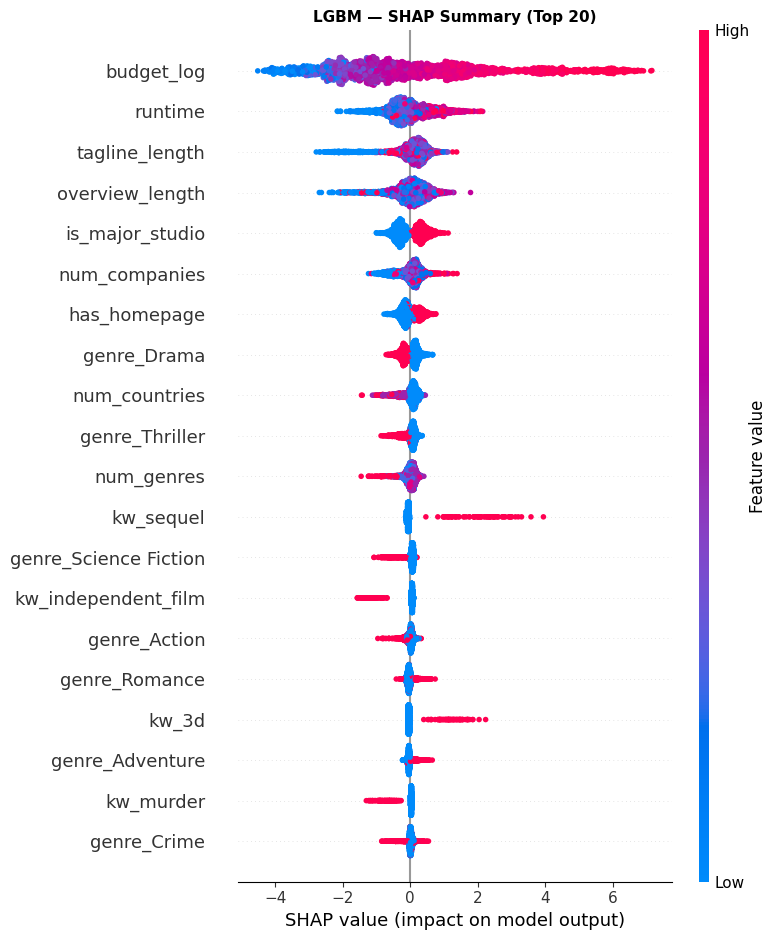

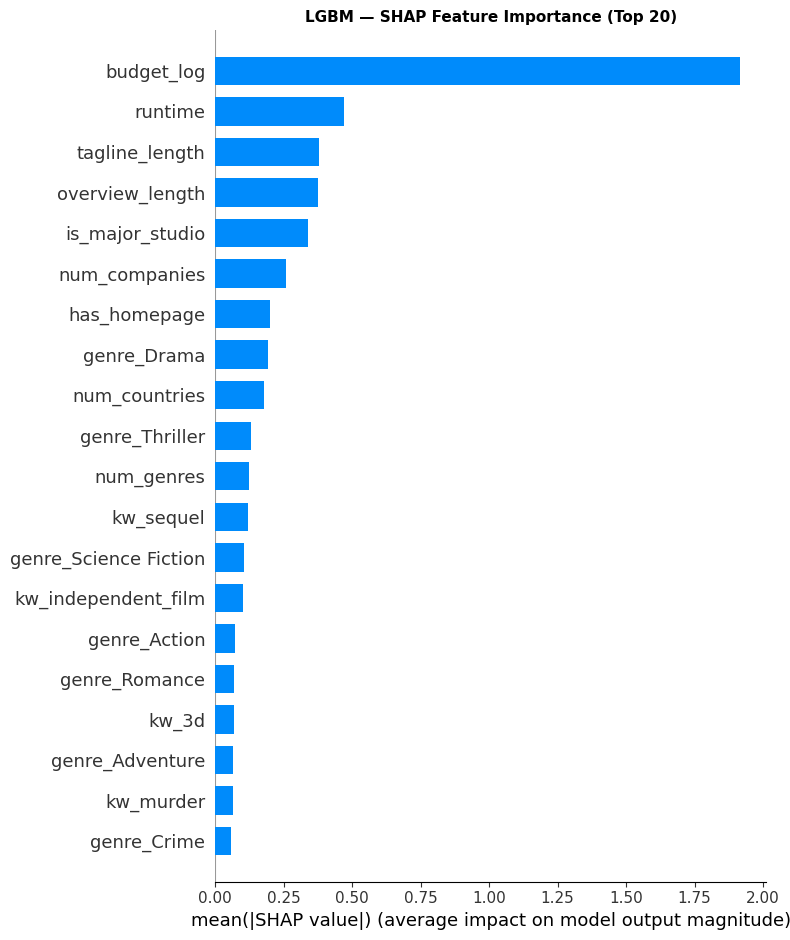

2026/04/15 19:29:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:29:22 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ baseline_lgbm_20260415_1929                        train=1.000  val=0.754  gap=+0.246
🏃 View run baseline_lgbm_20260415_1929 at: http://localhost:5000/#/experiments/1/runs/5a5df0e3480f4caca5c3df4ee1710f3f
🧪 View experiment at: http://localhost:5000/#/experiments/1


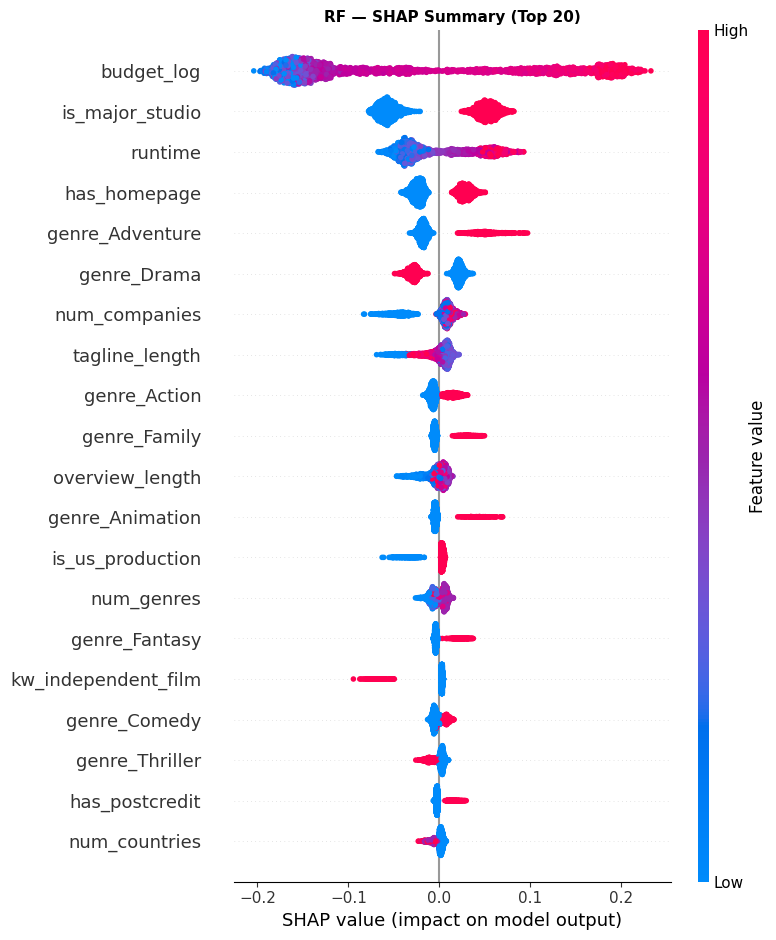

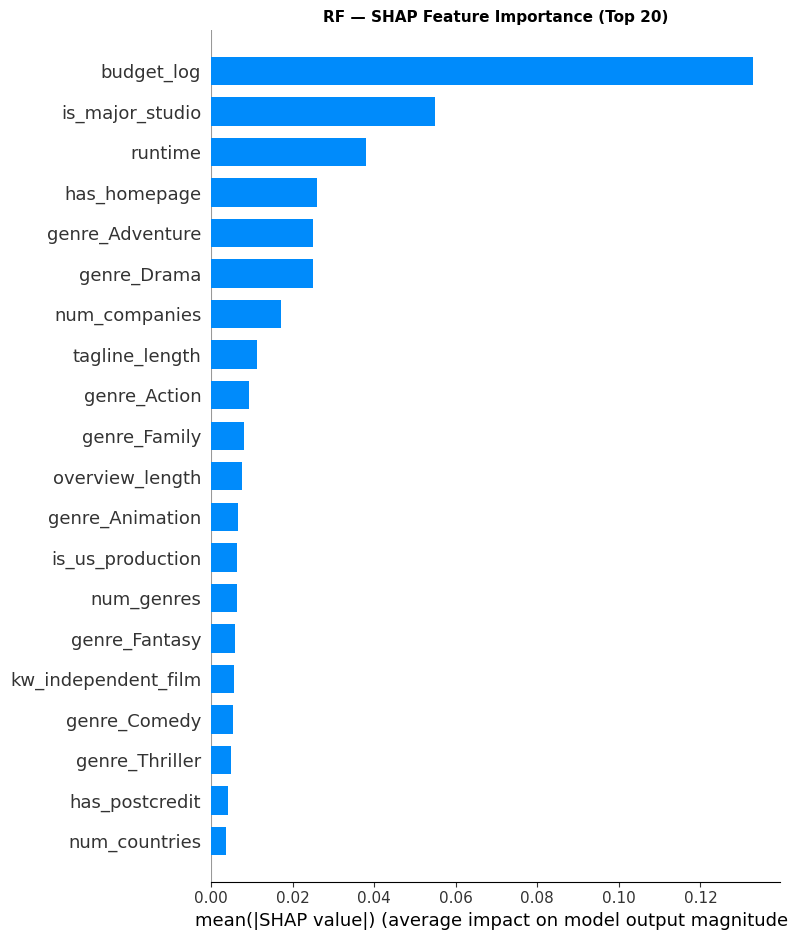

2026/04/15 19:29:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:29:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ baseline_rf_20260415_1929                          train=0.857  val=0.785  gap=+0.073
🏃 View run baseline_rf_20260415_1929 at: http://localhost:5000/#/experiments/1/runs/90305c4173e64a819b6f81cd82795a2e
🧪 View experiment at: http://localhost:5000/#/experiments/1


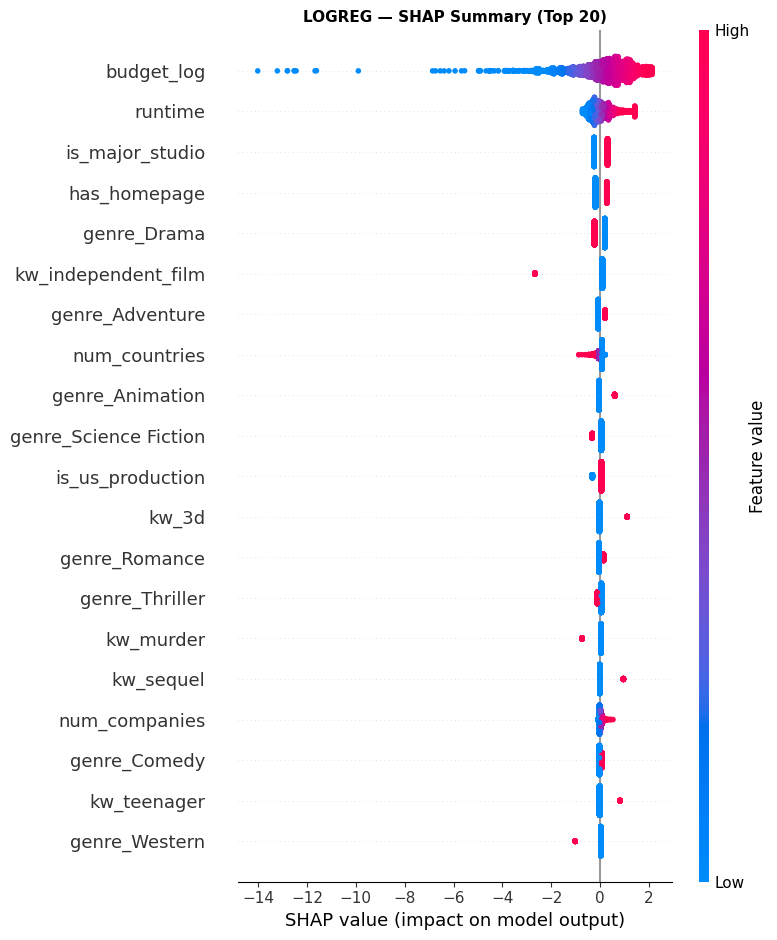

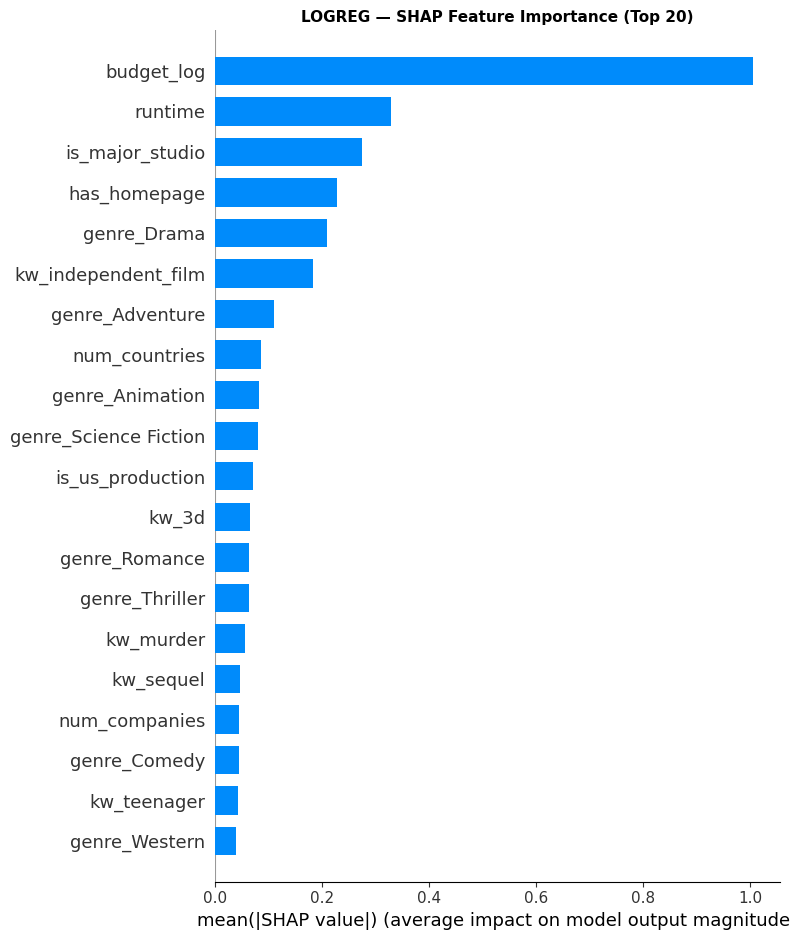

2026/04/15 19:29:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:29:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ baseline_logreg_20260415_1929                      train=0.791  val=0.762  gap=+0.029
🏃 View run baseline_logreg_20260415_1929 at: http://localhost:5000/#/experiments/1/runs/d2ce7dbef6594aaaafeffa84dd82e5de
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run session_A_20260415_1929 at: http://localhost:5000/#/experiments/1/runs/e31cfd1584f84fb994c2d56506072271
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ Oturum tamamlandı


In [8]:
models, results = train_session(DATASET_PATH, MODEL_CONFIGS, X_train, y_train, task_type=TASK_TYPE, scenario='A')

---
## 6 — Sonuçlar

In [9]:
main_metric = MAIN_METRIC[TASK_TYPE]

rows = []
for name, m in results.items():
    row = {'Model': name}
    row.update({k.upper(): round(v, 3) for k, v in m['val'].items()})
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Model').round(3)

print('=== Model Karşılaştırma Tablosu ===')
display(summary)

best = max(results, key=lambda k: results[k]['val'][main_metric])
best_model = models[best]
print(f'\n🏆 En iyi model: {best}  ({main_metric}={results[best]["val"][main_metric]:.3f})')

=== Model Karşılaştırma Tablosu ===


,ROC_AUC,F1,PRECISION,RECALL,AVG_PREC
Model,,,,,
lgbm,0.828,0.654,0.704,0.612,0.754
rf,0.851,0.692,0.667,0.719,0.785
logreg,0.837,0.681,0.621,0.754,0.762



🏆 En iyi model: rf  (avg_prec=0.785)


🏃 View run comparison_chart at: http://localhost:5000/#/experiments/1/runs/708dc0ad8481485fba2f989bd3b5f144
🧪 View experiment at: http://localhost:5000/#/experiments/1


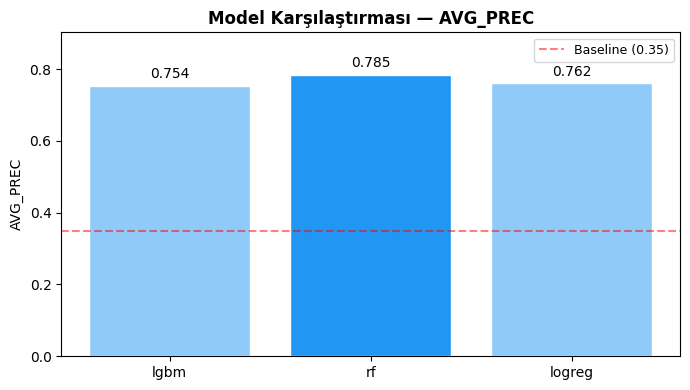

✓ Karşılaştırma grafiği MLflow'a kaydedildi


In [10]:
main_metric = MAIN_METRIC[TASK_TYPE]

fig, ax = plt.subplots(figsize=(7, 4))

names       = list(results.keys())
metric_vals = [results[n]['val'][main_metric] for n in names]
colors      = ['#2196F3' if n == best else '#90CAF9' for n in names]
bars = ax.bar(names, metric_vals, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.set_title(f'Model Karşılaştırması — {main_metric.upper()}', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(metric_vals) * 1.15)
ax.set_ylabel(main_metric.upper())
if TASK_TYPE in ('binary', 'multiclass'):
    ax.axhline(y=y.mean(), color='red', linestyle='--', alpha=0.5,
               label=f'Baseline ({y.mean():.2f})')
    ax.legend(fontsize=9)
plt.tight_layout()

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
with mlflow.start_run(run_name='comparison_chart',
                      experiment_id=experiment.experiment_id):
    mlflow.set_tag('type', 'summary')
    mlflow.log_figure(fig, 'model_comparison.png')

plt.show()
print('✓ Karşılaştırma grafiği MLflow\'a kaydedildi')

=== Overfitting / Underfitting Analizi ===


,Train AVG_PREC,Val AVG_PREC,Gap (Train−Val)
Model,,,
lgbm,1.000,0.754,0.246
rf,0.857,0.785,0.073
logreg,0.791,0.762,0.029


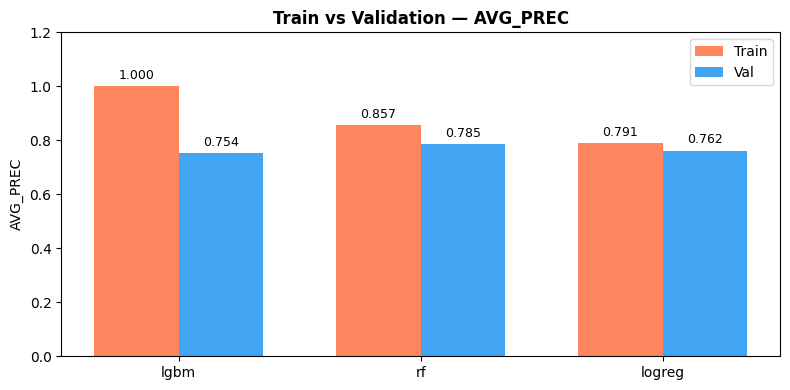

RuntimeError: Ciddi overfit — Model: lgbm | Gap: 0.246 > 0.2

In [11]:
# --- Katman 1: Tespit ---
main_metric = MAIN_METRIC[TASK_TYPE]

rows = []
for name, m in results.items():
    train_score = m['train'][main_metric]
    val_score   = m['val'][main_metric]
    gap         = train_score - val_score
    rows.append({
        'Model':                        name,
        f'Train {main_metric.upper()}': round(train_score, 3),
        f'Val {main_metric.upper()}':   round(val_score, 3),
        'Gap (Train−Val)':              round(gap, 3),
    })

gap_df = pd.DataFrame(rows).set_index('Model')
print('=== Overfitting / Underfitting Analizi ===')
display(gap_df)

# Grouped bar chart
names_list  = list(results.keys())
x           = np.arange(len(names_list))
w           = 0.35
train_vals  = [results[n]['train'][main_metric] for n in names_list]
val_vals    = [results[n]['val'][main_metric]   for n in names_list]

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - w/2, train_vals, w, label='Train', color='#FF7043', alpha=0.85)
bars2 = ax.bar(x + w/2, val_vals,   w, label='Val',   color='#2196F3', alpha=0.85)
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(names_list)
ax.set_title(f'Train vs Validation — {main_metric.upper()}',
             fontsize=12, fontweight='bold')
ax.set_ylabel(main_metric.upper())
ax.set_ylim(0, max(train_vals) * 1.2)
ax.legend()
plt.tight_layout()
plt.show()

# --- Katman 2: Karar ---
OVERFIT_STOP_THRESHOLD  = 0.20
UNDERFIT_STOP_THRESHOLD = 0.50

for name, m in results.items():
    gap       = m['train'][main_metric] - m['val'][main_metric]
    val_score = m['val'][main_metric]

    if gap > OVERFIT_STOP_THRESHOLD:
        raise RuntimeError(
            f"Ciddi overfit — Model: {name} | Gap: {gap:.3f} > {OVERFIT_STOP_THRESHOLD}"
        )

    if val_score < UNDERFIT_STOP_THRESHOLD:
        raise RuntimeError(
            f"Ciddi underfit — Model: {name} | Val: {val_score:.3f} < {UNDERFIT_STOP_THRESHOLD}"
        )

print("Tüm modeller eşik kontrolünden geçti — pipeline devam ediyor.")


---
## 7 — Baseline Feature Importance (Feature Selection için)

Hangi feature'ların düşük katkılı olduğunu belirlemek için baseline model üzerinde SHAP analizi.
Bu adımdan sonra gereksiz sütunlar `FEATURES` listesinden çıkarılabilir.

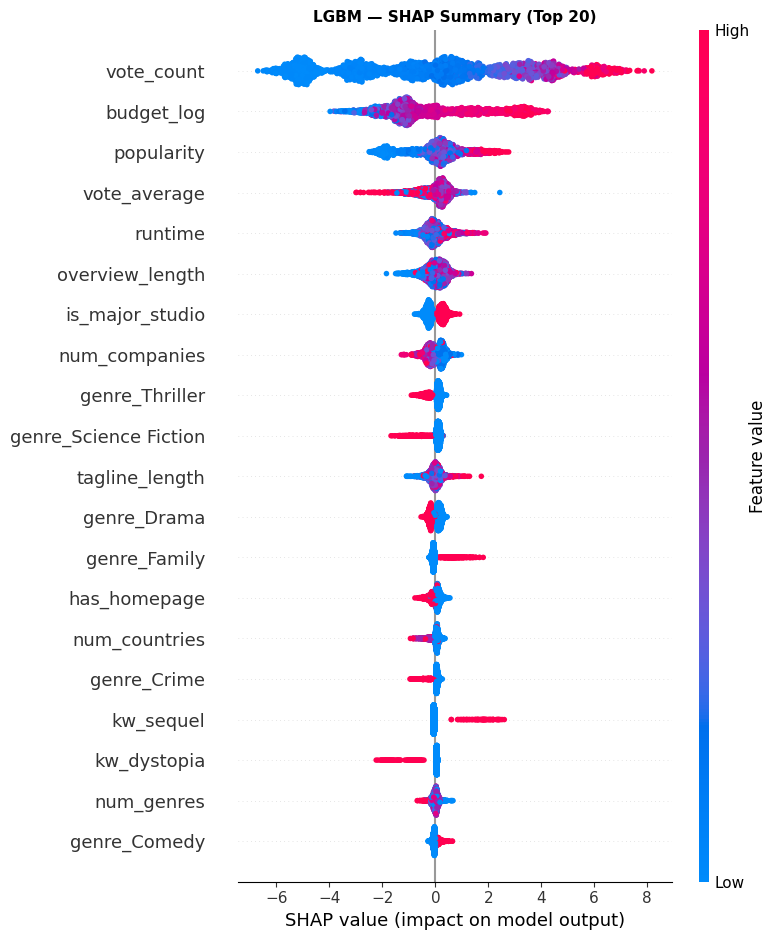

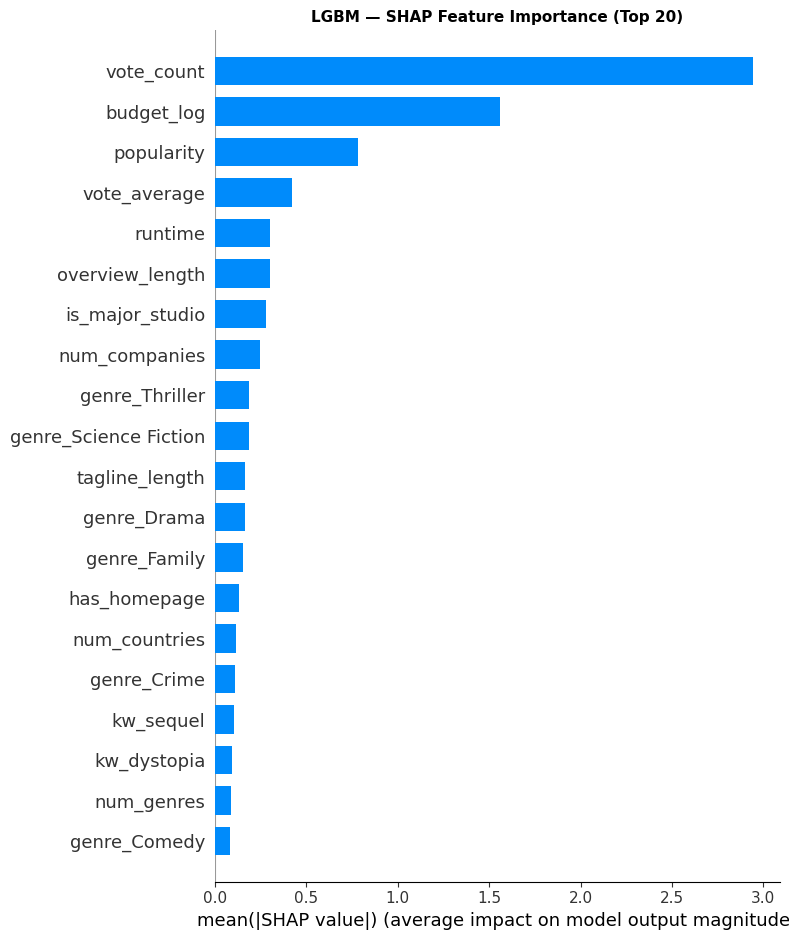

In [ ]:
shap_scores = log_shap(best_model, X_train, best, TASK_TYPE)

---
## 7.1 — Otomatik Feature Selection

Baseline SHAP skorlarına göre kümülatif katkının **%95**'ini oluşturan feature'lar seçilir.
Geri kalanlar Optuna tuning'e girmez.

In [ ]:
CUMULATIVE_THRESHOLD = 0.95   # toplam SHAP katkısının kaçta kaçı tutulacak

sorted_scores = shap_scores.sort_values(ascending=False)
cumsum        = sorted_scores.cumsum() / sorted_scores.sum()
cutoff        = int((cumsum < CUMULATIVE_THRESHOLD).sum()) + 1
selected_features = sorted_scores.index[:cutoff].tolist()

X_train = X_train[selected_features]
X_test  = X_test[selected_features]

print(f'Toplam feature   : {len(shap_scores)}')
print(f'Seçilen feature  : {len(selected_features)}  (%{CUMULATIVE_THRESHOLD*100:.0f} kümülatif SHAP katkısı)')
print(f'Elenen feature   : {len(shap_scores) - len(selected_features)}')
print(f'\nSeçilen feature listesi:\n{selected_features}')

# Feature listesini MLflow'a kaydet (inference için gerekli)
import json as _json
with mlflow.start_run(run_name=f'feature_selection_{best}',
                      experiment_id=mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id):
    mlflow.set_tags({'type': 'feature_selection', 'stage': 'feature_selection', 'model_type': best})
    mlflow.log_param('n_selected',          len(selected_features))
    mlflow.log_param('n_total',             len(shap_scores))
    mlflow.log_param('cumulative_threshold', CUMULATIVE_THRESHOLD)
    mlflow.log_text(_json.dumps(selected_features, ensure_ascii=False, indent=2),
                    'selected_features.json')
    print('✓ Feature listesi MLflow\'a kaydedildi')

Toplam feature   : 52
Seçilen feature  : 24  (%95 kümülatif SHAP katkısı)
Elenen feature   : 28

Seçilen feature listesi:
['vote_count', 'budget_log', 'popularity', 'vote_average', 'runtime', 'overview_length', 'is_major_studio', 'num_companies', 'genre_Thriller', 'genre_Science Fiction', 'tagline_length', 'genre_Drama', 'genre_Family', 'has_homepage', 'num_countries', 'genre_Crime', 'kw_sequel', 'kw_dystopia', 'num_genres', 'genre_Comedy', 'kw_3d', 'genre_Adventure', 'genre_Music', 'genre_Fantasy']
✓ Feature listesi MLflow'a kaydedildi
🏃 View run feature_selection_lgbm at: http://localhost:5000/#/experiments/1/runs/cb5d0f2683a049f89196ff5b844d8893
🧪 View experiment at: http://localhost:5000/#/experiments/1


---
## 8 — Hiperparametre Tuning (Optuna)

En iyi model `best` üzerinde Optuna ile hiperparametre optimizasyonu yapılıyor.
Diğer modellere dokunulmaz.

In [ ]:
from src.tuning import tune_model

main_metric    = MAIN_METRIC[TASK_TYPE]
baseline_score = results[best]['val'][main_metric]

best_model, study = tune_model(
    model_name     = best,
    X              = X_train,
    y              = y_train,
    task_type      = TASK_TYPE,
    baseline_score = baseline_score,
    n_trials       = 50,
)


Optuna başlıyor — model: lgbm  |  metrik: avg_prec  |  trial: 50


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.8692
  Tuned     avg_prec: 0.8786
  İyileşme : +0.0094

  En iyi parametreler:
    n_estimators: 268
    learning_rate: 0.011196847698587913
    num_leaves: 26
    min_child_samples: 10
    reg_alpha: 0.021740854167380832
    reg_lambda: 0.00015547361664432964

✓ best_model güncellendi — tuned lgbm


2026/04/15 14:42:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 14:42:26 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_lgbm_20260415_1442 at: http://localhost:5000/#/experiments/1/runs/9333b1120dff42dba7f7f83201119284
🧪 View experiment at: http://localhost:5000/#/experiments/1


---
## 9 — Tuned Model Feature Importance

Optuna ile optimize edilmiş final model üzerinde SHAP analizi.
Baseline SHAP ile karşılaştırarak tuning'in feature ağırlıklarını nasıl değiştirdiği görülebilir.

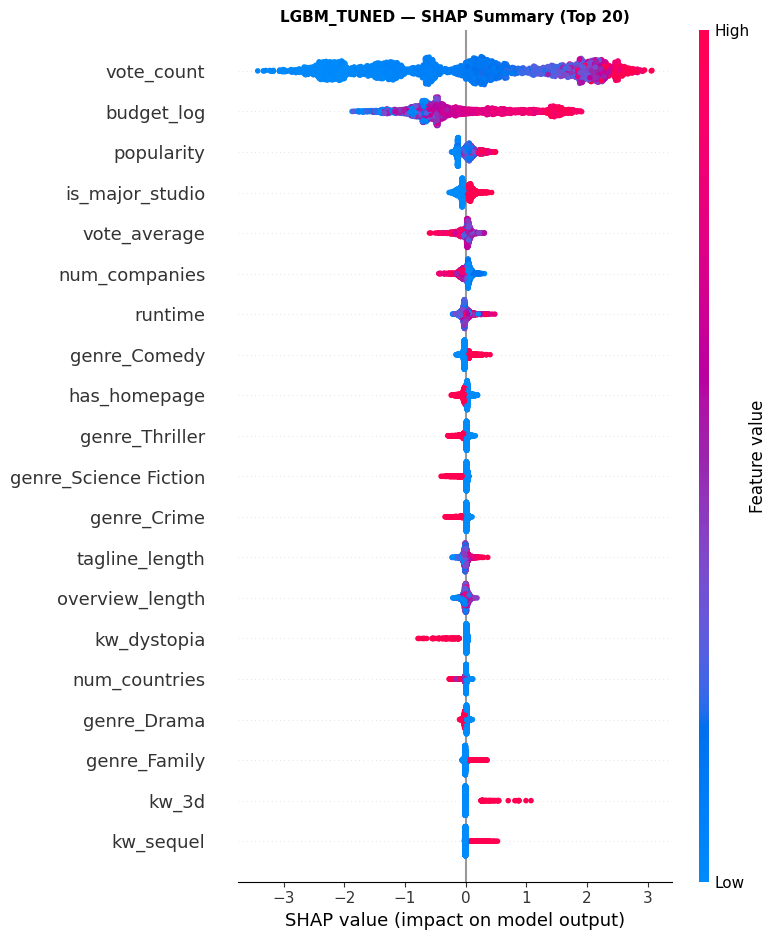

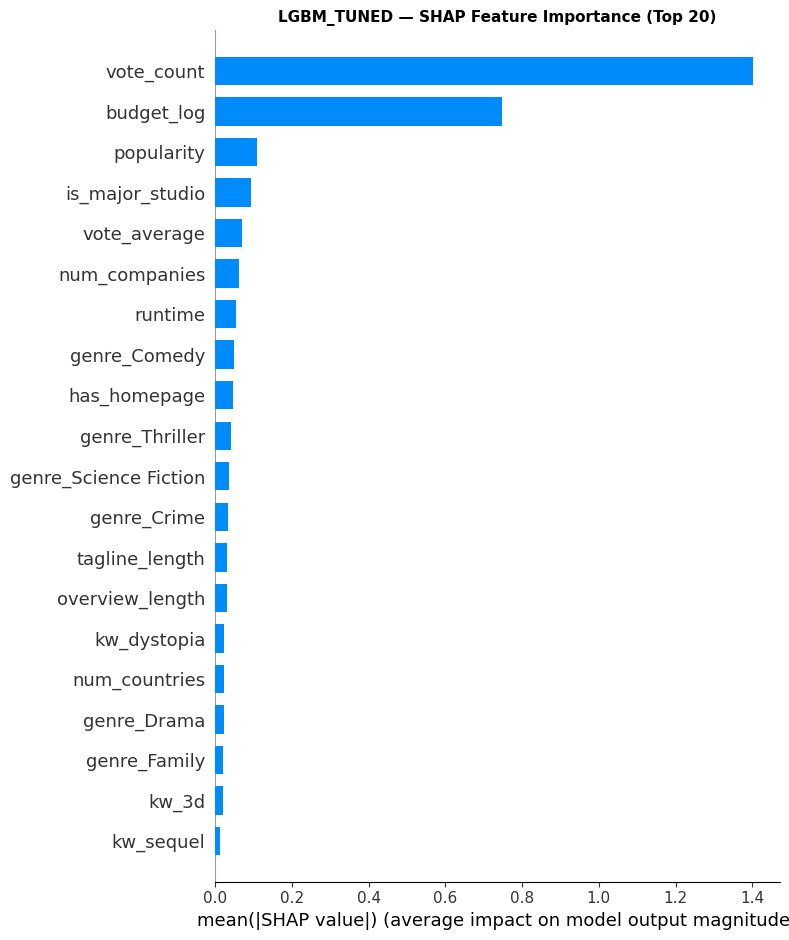

vote_count               1.402097
budget_log               0.747786
popularity               0.109875
vote_average             0.071150
runtime                  0.054900
overview_length          0.030547
is_major_studio          0.093847
num_companies            0.062942
genre_Thriller           0.040320
genre_Science Fiction    0.035086
tagline_length           0.032193
genre_Drama              0.022010
genre_Family             0.021046
has_homepage             0.045932
num_countries            0.022744
genre_Crime              0.033897
kw_sequel                0.013831
kw_dystopia              0.024052
num_genres               0.006720
genre_Comedy             0.048354
kw_3d                    0.019471
genre_Adventure          0.013417
genre_Music              0.009935
genre_Fantasy            0.000140
dtype: float64

In [ ]:
log_shap(best_model, X_train, f'{best}_tuned', TASK_TYPE)

---
## 10 — Test Seti Değerlendirmesi

En iyi model **test seti** üzerinde değerlendiriliyor.  
Bu noktaya kadar test seti hiç açılmadı — bu skor gerçek genelleme performansıdır.

=== LGBM — Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       421
           1       0.85      0.71      0.77       225

    accuracy                           0.86       646
   macro avg       0.85      0.82      0.83       646
weighted avg       0.86      0.86      0.85       646

=== LGBM — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.869,0.893,0.024
ROC-AUC,0.915,0.936,0.021
F1,0.767,0.775,0.008
Precision,0.794,0.851,0.057
Recall,0.742,0.711,-0.031


✓ Test metrikleri ve görselleştirme MLflow'a kaydedildi
🏃 View run test_eval_lgbm at: http://localhost:5000/#/experiments/1/runs/8caee9fc54594558befc75a83eedcad5
🧪 View experiment at: http://localhost:5000/#/experiments/1


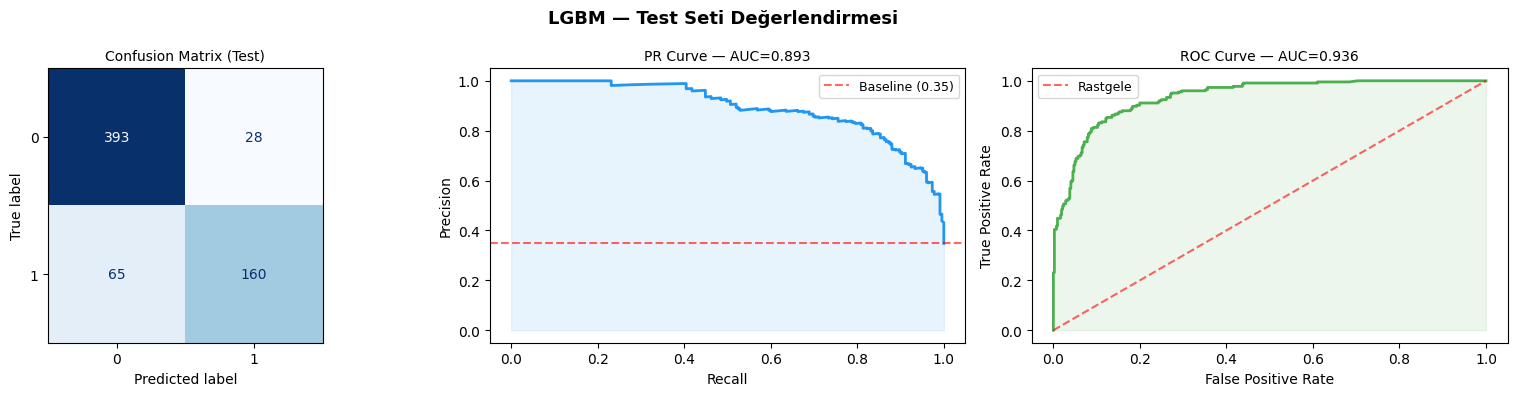

In [ ]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)
if TASK_TYPE in ('binary', 'multiclass'):
    print(f'=== {best.upper()} — Classification Report (Test) ===')
    print(classification_report(y_test, y_pred))

if TASK_TYPE in ('binary', 'multiclass'):
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]
    test_metrics = {
        'PR-AUC'   : average_precision_score(y_test, y_pred_prob),
        'ROC-AUC'  : roc_auc_score(y_test, y_pred_prob),
        'F1'       : f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
    }
    cv_keys = {
        'PR-AUC':    'avg_prec',
        'ROC-AUC':   'roc_auc',
        'F1':        'f1',
        'Precision': 'precision',
        'Recall':    'recall',
    }
else:
    y_pred_prob = None
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    test_metrics = {
        'RMSE': float(np.sqrt(mean_squared_error(y_test, y_pred))),
        'MAE' : float(mean_absolute_error(y_test, y_pred)),
        'R2'  : float(r2_score(y_test, y_pred)),
    }
    cv_keys = {'RMSE': 'rmse', 'MAE': 'mae', 'R2': 'r2'}

cv_metrics = results[best]['val']

comparison = pd.DataFrame({
    'CV (val)': {k: round(cv_metrics[v], 3) for k, v in cv_keys.items()},
    'Test'      : {k: round(test_metrics[k], 3) for k in cv_keys},
})
comparison['Fark'] = (comparison['Test'] - comparison['CV (val)']).round(3)

print(f'=== {best.upper()} — CV vs Test Karşılaştırması ===')
display(comparison)

# Görselleştirme
if TASK_TYPE in ('binary', 'multiclass'):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'{best.upper()} — Test Seti Değerlendirmesi', fontsize=13, fontweight='bold')

    cm = confusion_matrix(y_test, y_pred)
    labels = sorted(pd.Series(y_test).unique().tolist())
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=axes[0], colorbar=False, cmap='Blues'
    )
    axes[0].set_title('Confusion Matrix (Test)', fontsize=10)

    prec, rec, _ = precision_recall_curve(y_test, y_pred_prob)
    axes[1].plot(rec, prec, color='#2196F3', lw=2)
    axes[1].axhline(y=y_test.mean(), color='red', linestyle='--', alpha=0.6,
                    label=f'Baseline ({y_test.mean():.2f})')
    axes[1].fill_between(rec, prec, alpha=0.1, color='#2196F3')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'PR Curve — AUC={test_metrics["PR-AUC"]:.3f}', fontsize=10)
    axes[1].legend(fontsize=9)

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    axes[2].plot(fpr, tpr, color='#4CAF50', lw=2)
    axes[2].plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.6, label='Rastgele')
    axes[2].fill_between(fpr, tpr, alpha=0.1, color='#4CAF50')
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].set_title(f'ROC Curve — AUC={test_metrics["ROC-AUC"]:.3f}', fontsize=10)
    axes[2].legend(fontsize=9)
else:
    residuals = y_test - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(f'{best.upper()} — Test Seti Değerlendirmesi', fontsize=13, fontweight='bold')

    axes[0].scatter(y_pred, residuals, alpha=0.3, s=10)
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_xlabel('Tahmin')
    axes[0].set_ylabel('Artık')
    axes[0].set_title('Residual Plot (Test)', fontsize=10)

    axes[1].hist(residuals, bins=40, color='#2196F3', edgecolor='white')
    axes[1].set_title('Artık Dağılımı (Test)', fontsize=10)

plt.tight_layout()

# MLflow'a test metriklerini ve görselleştirmeyi logla
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
with mlflow.start_run(run_name=f'test_eval_{best}',
                      experiment_id=experiment.experiment_id):
    mlflow.set_tag('type', 'test_evaluation')
    mlflow.set_tag('stage', 'test')
    mlflow.set_tag('model', best)
    mlflow.log_metrics({f'test_{k.lower().replace("-","_")}': v
                        for k, v in test_metrics.items()})
    mlflow.log_figure(fig, 'test_evaluation.png')
    import shutil, tempfile
    nb_name = f'train_{datetime.now():%Y%m%d_%H%M%S}.ipynb'
    tmp_path = Path(tempfile.gettempdir()) / nb_name
    shutil.copy('train.ipynb', tmp_path)
    mlflow.log_artifact(str(tmp_path), artifact_path='notebooks')
    tmp_path.unlink()
    print(f'✓ Test metrikleri ve görselleştirme MLflow\'a kaydedildi')
    print(f'✓ Notebook MLflow\'a kaydedildi → notebooks/{nb_name}')

plt.show()
plt.close(fig)

---
## 11 — MLflow UI

Container'ı başlatmak için terminalde çalıştır:

```bash
make up-mlflow
```

Sonra tarayıcıda aç: `http://localhost:5000`

Diğer komutlar:

```bash
make logs-mlflow     # logları izle
make down-mlflow     # durdur
make backup-mlflow   # yedekle
make nuke-mlflow     # tüm verileri sil
```

In [ ]:
# Kaydedilen model run'larını listele (session ve summary run'ları hariç)
runs = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    filter_string="tags.type = 'baseline'",
    order_by=[f'metrics.{main_metric} DESC']
)

display_cols = [
    'tags.scenario', 'tags.model_type',
    'metrics.avg_prec', 'metrics.roc_auc',
    'metrics.f1', 'metrics.precision', 'metrics.recall'
]
display_cols = [c for c in display_cols if c in runs.columns]

print('=== MLflow Kayıtlı Run\'lar ===')
display(runs[display_cols].rename(columns={
    'tags.scenario': 'Senaryo',
    'tags.model_type': 'Model',
    'metrics.avg_prec': 'PR-AUC',
    'metrics.roc_auc': 'ROC-AUC',
    'metrics.f1': 'F1',
    'metrics.precision': 'Precision',
    'metrics.recall': 'Recall',
}).round(3))

=== MLflow Kayıtlı Run'lar ===


,Senaryo,Model,PR-AUC,ROC-AUC,F1,Precision,Recall
0,A,lgbm,0.869,0.915,0.767,0.794,0.742
1,A,rf,0.869,0.916,0.773,0.725,0.828
2,A,logreg,0.844,0.898,0.756,0.721,0.794


---
## 12 — Experiment Raporu

Tüm MLflow run'ları çekilerek otomatik markdown raporu üretilir ve artifact olarak loglanır.

In [ ]:
from src.reporting import generate_experiment_report

report = generate_experiment_report(
    experiment_name = EXPERIMENT_NAME,
    task_type       = TASK_TYPE,
    dataset_path    = DATASET_PATH,
    n_samples       = len(df_model),
    hit_rate        = y.mean(),
    n_features      = len(FEATURES),
)

print(report)
